# Distributional Regression & Specifying Causal Margin

In [1]:
import sys, os
import numpy as np
import pickle
import os
from tqdm import tqdm
import torch.nn as nn
import torch.distributions as dist
import torch.special as special
from scipy.stats import norm

# add the project root to sys.path
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root not in sys.path:
    sys.path.insert(0, root)

from data_causl.utils import *
from data_causl.data import *
from frengression import *
import src.exp_utils as exp_utils
from engression.models import StoNet, StoNetBase

device = torch.device('cpu')

from matplotlib import pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

normal = dist.Normal(0., 1.)
class SpecifiedCausalMargin(StoNetBase):
    def __init__(self, ate, noise_dim, eta_dist, x_dim):
        super().__init__(noise_dim=noise_dim)
        self.ate = ate  # or self.register_buffer('eta', torch.tensor(eta))
        self.x_dim = x_dim
        self.eta_dist = eta_dist

    def forward(self, x):
        if x.shape[1]==self.x_dim:
            if self.eta_dist == 'gamma':
                # per‐element alpha, beta
                alpha_arr = torch.full(x.shape, 2.0, device=x.device)
                beta_arr  = torch.full(x.shape, 1.0, device=x.device)
                gamma_dist = torch.distributions.Gamma(alpha_arr, beta_arr)
                eta = gamma_dist.sample()
            if self.eta_dist == 'gaussian':
                eta = torch.randn(x.shape, device=x.device)
            if self.eta_dist == 'laplace':
                lap  = dist.Laplace(0, 0.5)
                eta  = lap.sample(x.shape,device=x.device)
            if self.eta_dist == 'lognormal':
                lognorm = dist.LogNormal(0, 1)
                eta     = lognorm.sample(x.shape).to(x.device)
        else:
            x_eta = x.clone()
            x = x_eta[:, :self.x_dim]
            eta_inp = x_eta[:, self.x_dim:]
            if self.eta_dist== 'gaussian':
                eta = eta_inp  
            if self.eta_dist == 'gamma':
                alpha = torch.full_like(eta_inp, 2.0)
                beta  = torch.full_like(eta_inp, 1.0)
                u = dist.Normal(0, 1).cdf(eta_inp)
                u = u.clamp(min=1e-6, max=1 - 1e-6)
                eta = special.gammaincinv(alpha, u) / beta
            if self.eta_dist == 'laplace':
                u = dist.Normal(0, 1).cdf(eta_inp)
                u = u.clamp(min=1e-6, max=1-1e-6)
                eta = torch.where(
                    u < 0.5,
                    0 +  0.5*torch.log(2 * u),
                    0 -  0.5* torch.log(2 * (1 - u))
                )
            if self.eta_dist == 'lognormal':
                u = normal.cdf(eta_inp).clamp(min=1e-6, max=1 - 1e-6)
                z = normal.icdf(u)     # which is exactly eta_inp
                eta = torch.exp(z)
            # if self.eta_dist == 'lognormal':
            #     eta   = torch.exp(0 + 1 * eta_inp)

        # other distributions can be implemented likewise
        return self.ate * x + eta

# Helper function for MMD
def mmd_rbf(x, y, sigma=1.0):
    """Compute MMD between two distributions using RBF kernel."""
    pairwise_sq_dists = squareform(pdist(np.vstack([x, y]), 'sqeuclidean'))
    K = np.exp(-pairwise_sq_dists / (2 * sigma ** 2))
    K_xx = K[:len(x), :len(x)]
    K_xy = K[:len(x), len(x):]
    K_yy = K[len(x):, len(x):]
    mmd = np.mean(K_xx) - 2 * np.mean(K_xy) + np.mean(K_yy)
    return mmd


np.random.seed(42)

nI = 2
nX = 0
nO = 2
nS= 2
p = nI+nX+nO+nS
ate = 2
beta_cov = 0
strength_instr = 0
strength_conf = 0
strength_outcome = 1
binary_intervention=True

In [2]:
df_tr = generate_data_causl(n=5000, nI =nI, nX= nX, nO = nO, nS = nS, ate = ate, beta_cov = beta_cov, strength_instr = strength_instr, strength_conf = strength_conf, strength_outcome =strength_outcome, binary_intervention=binary_intervention)
z_tr = torch.tensor(df_tr[[f"X{i}" for i in range(1, p + 1)]].values, dtype=torch.float32)
x_tr = torch.tensor(df_tr['A'].values, dtype=torch.int32).view(-1, 1)
y_tr = torch.tensor(df_tr['y'].values, dtype=torch.float32).view(-1, 1)

In [3]:
model = Frengression(
        x_tr.shape[1], y_tr.shape[1], z_tr.shape[1],
        noise_dim=1, num_layer=3, hidden_dim=100,
        device=device, x_binary=binary_intervention
    )

In [23]:
# model.train_y(x_tr, z_tr, y_tr, num_iters=3000, lr=1e-4, print_every_iter=500,tol=0.000)

In [24]:
# model.train_xz(x_tr, z_tr, num_iters=2000, lr=1e-4, print_every_iter=500)

In [13]:
# torch.save(model,"result/model_distributional.pt")
model = torch.load("result/model_distributional.pt", weights_only=False)

In [14]:
# Sample causal margins
x0_samples = model.sample_causal_margin(x=torch.tensor([[0]], dtype=torch.int32), sample_size=5000).numpy().flatten()
x1_samples = model.sample_causal_margin(x=torch.tensor([[1]], dtype=torch.int32), sample_size=5000).numpy().flatten()
sampled_x,sampled_y,sampled_z = model.sample_joint(sample_size=5000)

margin_module = SpecifiedCausalMargin(ate=5, eta_dist="gaussian", x_dim=model.x_dim, noise_dim=model.noise_dim)
model.specify_causal(causal_margin=margin_module)
sampled_x_5x,sampled_y_5x,sampled_z_5x = model.sample_joint(sample_size=5000)

margin_module = SpecifiedCausalMargin(ate=2, noise_dim=model.noise_dim, eta_dist = 'laplace',x_dim = x_tr.shape[1])
model.specify_causal(causal_margin=margin_module)
sampled_x_2x,sampled_y_2x,sampled_z_2x = model.sample_joint(sample_size=5000)

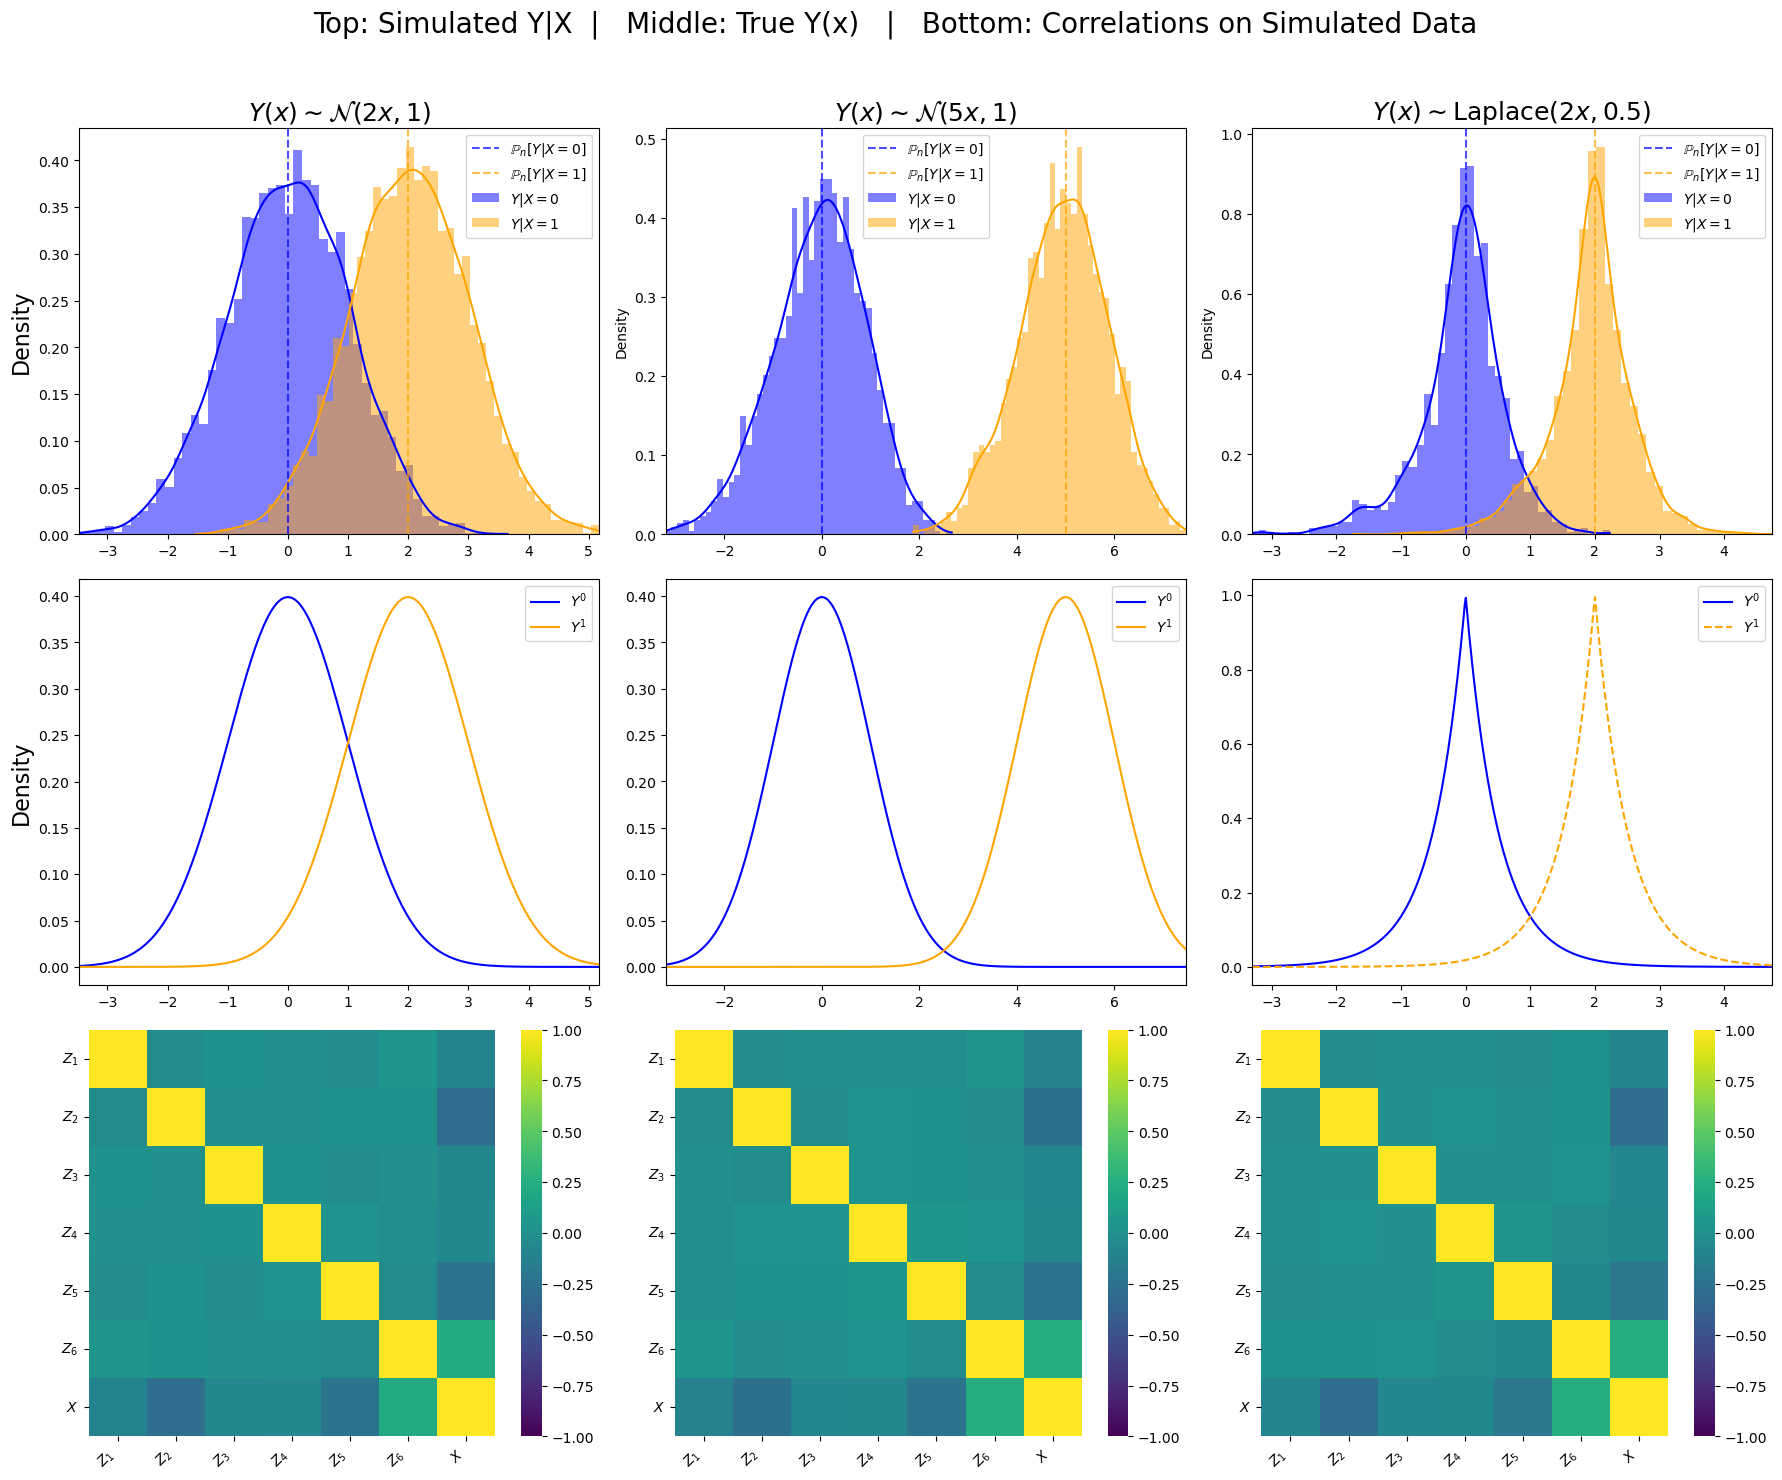

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, laplace

# — your data arrays must already be defined — 
# x0_samples, x1_samples               
# sampled_x_5x, sampled_y_5x           
# sampled_x_0x, sampled_y_0x           
# z0_samples, z1_samples               # shape (n_obs, p)
# sampled_z_5x, sampled_z_0x           # shape (n_obs, p)
# sampled_z, sampled_x                 # combined marginals for col-0

fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey=False)


# Compute per-column x-limits
y0 = np.concatenate([np.ravel(x0_samples), np.ravel(x1_samples)])
xmin0, xmax0 = y0.min(), y0.max()
y1 = np.ravel(sampled_y_5x); xmin1, xmax1 = y1.min(), y1.max()
y2 = np.ravel(sampled_y_2x); xmin2, xmax2 = y2.min(), y2.max()

# Common histogram + KDE styling
hist_args = dict(
    stat="density",
    bins=50,
    kde=True,           # fit & plot KDE
    edgecolor=None,
    alpha=0.5
)

### Row 1: simulated marginals ###
# Col 0
sns.histplot(x0_samples, color='blue', label='$Y|X=0$', ax=axes[0,0], **hist_args)
sns.histplot(x1_samples, color='orange', label='$Y|X=1$', ax=axes[0,0], **hist_args)
axes[0,0].axvline(0, linestyle='--', color='blue',
                  label=r'$\mathbb{P}_n[Y|X=0]$', alpha=0.7)
axes[0,0].axvline(2, linestyle='--', color='orange',
                  label=r'$\mathbb{P}_n[Y|X=1]$', alpha=0.7)
axes[0,0].set_title(r"$Y(x) \sim\mathcal{N}(2x,1)$", fontsize=18)
axes[0,0].set_xlim(xmin0, xmax0)
axes[0,0].legend()
axes[0,0].set_ylabel("Density",fontsize=16)

# Col 1
sns.histplot(sampled_y_5x[sampled_x_5x==0], color='blue',
             label='$Y|X=0$', ax=axes[0,1], **hist_args)
sns.histplot(sampled_y_5x[sampled_x_5x==1], color='orange',
             label='$Y|X=1$', ax=axes[0,1], **hist_args)
axes[0,1].axvline(0, linestyle='--', color='blue',
                  label=r'$\mathbb{P}_n[Y|X=0]$', alpha=0.7)
axes[0,1].axvline(5, linestyle='--', color='orange',
                  label=r'$\mathbb{P}_n[Y|X=1]$', alpha=0.7)
axes[0,1].set_title(r"$Y(x)\sim\mathcal{N}(5x,1)$", fontsize=18)
axes[0,1].set_xlim(xmin1, xmax1)
axes[0,1].legend()

# Col 2
sns.histplot(sampled_y_2x[sampled_x_2x==0], color='blue',
             label='$Y|X=0$', ax=axes[0,2], **hist_args)
sns.histplot(sampled_y_2x[sampled_x_2x==1], color='orange',
             label='$Y|X=1$', ax=axes[0,2], **hist_args)
axes[0,2].axvline(0, linestyle='--', color='blue',
                  label=r'$\mathbb{P}_n[Y|X=0]$', alpha=0.7)
axes[0,2].axvline(2, linestyle='--', color='orange',
                label=r'$\mathbb{P}_n[Y|X=1]$', alpha=0.7)
axes[0,2].set_title(r"$Y(x)\sim \operatorname{Laplace}(2x,0.5)$",fontsize=18)
axes[0,2].set_xlim(xmin2, xmax2)
axes[0,2].legend()



### Row 2: ground-truth marginals ###
ygrid0 = np.linspace(xmin0, xmax0, 500)
ygrid1 = np.linspace(xmin1, xmax1, 500)
ygrid2 = np.linspace(xmin2, xmax2, 500)

# Col 0
axes[1,0].plot(ygrid0, norm.pdf(ygrid0, loc=0, scale=1),
               label='$Y^0$', color='blue')
axes[1,0].plot(ygrid0, norm.pdf(ygrid0, loc=2, scale=1),
               label='$Y^1$', color='orange')
axes[1,0].set_xlim(xmin0, xmax0)
axes[1,0].legend()
axes[1,0].set_ylabel("Density", fontsize=16)

# Col 1
axes[1,1].plot(ygrid1, norm.pdf(ygrid1, loc=0, scale=1),
               label='$Y^0$', color='blue')
axes[1,1].plot(ygrid1, norm.pdf(ygrid1, loc=5, scale=1),
               label='$Y^1$', color='orange')
axes[1,1].set_xlim(xmin1, xmax1)
axes[1,1].legend()

# Col 2
axes[1,2].plot(ygrid2, laplace.pdf(ygrid2, loc=0, scale=0.5),
               label='$Y^0$', color='blue')
axes[1,2].plot(ygrid2, laplace.pdf(ygrid2, loc=2, scale=0.5),
               label='$Y^1$', color='orange', linestyle='--')
axes[1,2].set_xlim(xmin2, xmax2)
axes[1,2].legend()


### Row 3: correlation heatmaps of (Z₁,…,Zₚ, X) ###
def corr_heatmap(z, x, ax):
    z_arr = np.asarray(z)
    x_arr = np.asarray(x).ravel()
    n, p = z_arr.shape
    df = pd.DataFrame(z_arr, columns=[f'Z_{i+1}' for i in range(p)])
    df['X'] = x_arr
    corr = df.corr()
    sns.heatmap(
        corr, annot=False,
        cmap='viridis', vmin=-1, vmax=1,
        square=True, ax=ax
    )
    labels = [rf'$Z_{{{i+1}}}$' for i in range(p)] + ['$X$']
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)


# Col 0: combined marginals
corr_heatmap(sampled_z, sampled_x, axes[2,0])

# Col 1: joint ATE=5
corr_heatmap(sampled_z_5x, sampled_x_5x, axes[2,1])

# Col 2: joint ATE=0
corr_heatmap(sampled_z_2x, sampled_x_2x, axes[2,2])

# Final layout
plt.suptitle(
    "Top: Simulated Y|X  |   Middle: True Y(x)   |   Bottom: Correlations on Simulated Data",
    fontsize=20, y=0.98
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


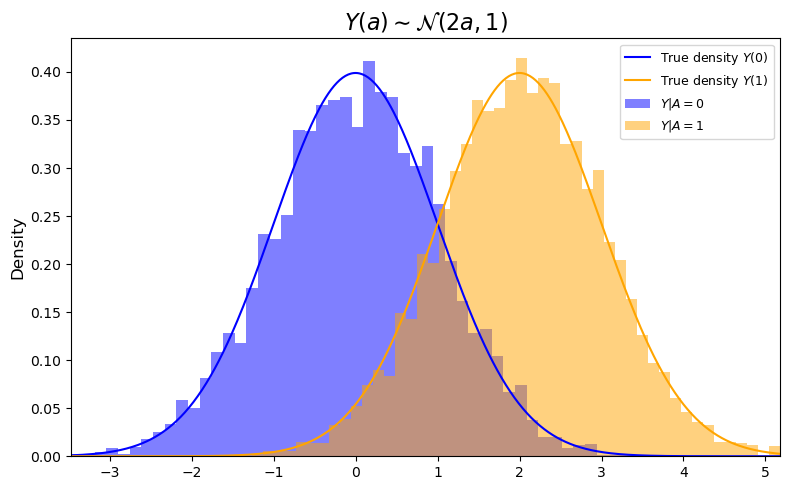

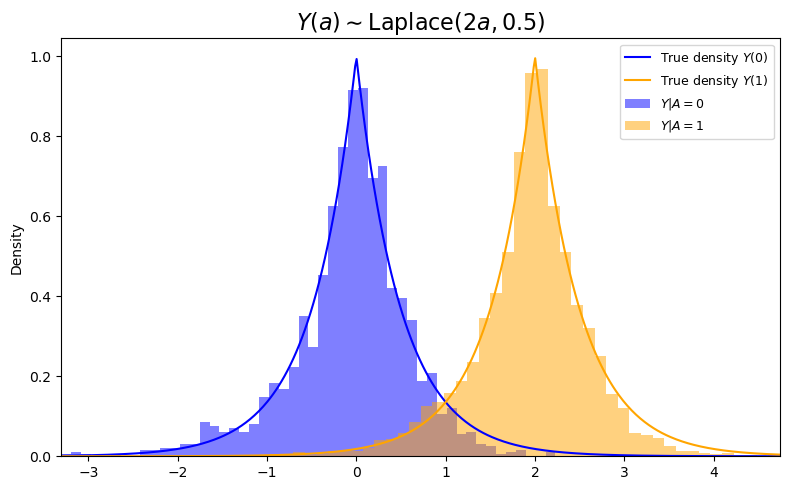

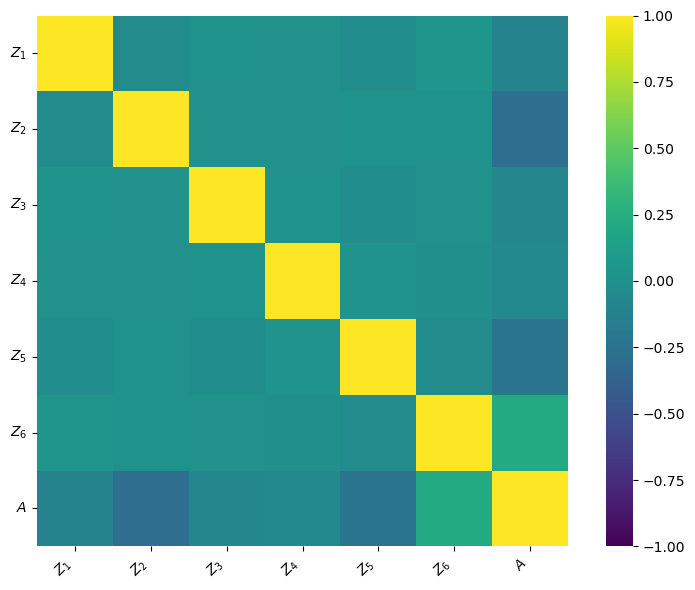

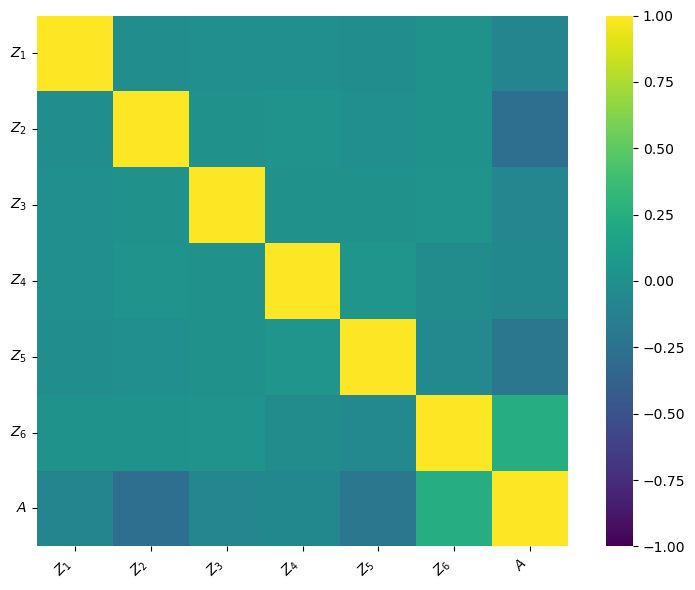

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, laplace

# — your data arrays must already be defined — 
# x0_samples, x1_samples               
# sampled_x_5x, sampled_y_5x           
# sampled_x_2x, sampled_y_2x           
# z0_samples, z1_samples               # shape (n_obs, p)
# sampled_z_5x, sampled_z_2x           # shape (n_obs, p)
# sampled_z, sampled_x                 # combined marginals for col-0

# Compute per-column x-limits (same logic as before)
y0 = np.concatenate([np.ravel(x0_samples), np.ravel(x1_samples)])
xmin0, xmax0 = y0.min(), y0.max()
y1 = np.ravel(sampled_y_5x); xmin1, xmax1 = y1.min(), y1.max()
y2 = np.ravel(sampled_y_2x); xmin2, xmax2 = y2.min(), y2.max()

# Common histogram styling: remove fitted KDE (kde=False)
hist_args = dict(
    stat="density",
    bins=50,
    kde=False,          # DO NOT fit & plot KDE
    edgecolor=None,
    alpha=0.5
)

# ---------------------------
# Figure 1: Left-top (histograms for x0_samples / x1_samples) with true densities
# ---------------------------
plt.figure(figsize=(8, 5))
ax = plt.gca()

sns.histplot(x0_samples, color='blue', label='$Y|A=0$', ax=ax, **hist_args)
sns.histplot(x1_samples, color='orange', label='$Y|A=1$', ax=ax, **hist_args)

ygrid0 = np.linspace(xmin0, xmax0, 500)
ax.plot(ygrid0, norm.pdf(ygrid0, loc=0, scale=1),
        label='True density $Y(0)$', color='blue', linestyle='-')
ax.plot(ygrid0, norm.pdf(ygrid0, loc=2, scale=1),
        label='True density $Y(1)$', color='orange', linestyle='-')

ax.set_title(r"$Y(a) \sim \mathcal{N}(2a,1)$", fontsize=16)
ax.set_xlim(xmin0, xmax0)
ax.legend(fontsize=9)
ax.set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()


# ---------------------------
# Figure 2: Right-top (histograms for sampled_y_2x conditioned on sampled_x_2x) with true densities
# ---------------------------
plt.figure(figsize=(8, 5))
ax = plt.gca()

sns.histplot(sampled_y_2x[sampled_x_2x==0], color='blue',
             label='$Y|A=0$', ax=ax, **hist_args)
sns.histplot(sampled_y_2x[sampled_x_2x==1], color='orange',
             label='$Y|A=1$', ax=ax, **hist_args)

ygrid2 = np.linspace(xmin2, xmax2, 500)
ax.plot(ygrid2, laplace.pdf(ygrid2, loc=0, scale=0.5),
        label='True density $Y(0)$', color='blue', linestyle='-')
ax.plot(ygrid2, laplace.pdf(ygrid2, loc=2, scale=0.5),
        label='True density $Y(1)$', color='orange', linestyle='-')

ax.set_title(r"$Y(a)\sim \operatorname{Laplace}(2a,0.5)$", fontsize=16)
ax.set_xlim(xmin2, xmax2)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


# ---------------------------
# corr_heatmap helper (same as your function)
# ---------------------------
def corr_heatmap(z, a, ax):
    z_arr = np.asarray(z)
    a_arr = np.asarray(a).ravel()
    n, p = z_arr.shape
    df = pd.DataFrame(z_arr, columns=[f'Z_{i+1}' for i in range(p)])
    df['A'] = a_arr
    corr = df.corr()
    sns.heatmap(
        corr, annot=False,
        cmap='viridis', vmin=-1, vmax=1,
        square=True, ax=ax
    )
    labels = [rf'$Z_{{{i+1}}}$' for i in range(p)] + ['$A$']
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)


# ---------------------------
# Figure 3: Left-bottom heatmap (combined marginals)
# ---------------------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
corr_heatmap(sampled_z, sampled_x, ax)
# If you want a title on the heatmap figure, you can set it; original code did not set explicit per-axes titles for heatmaps.
plt.tight_layout()
plt.show()


# ---------------------------
# Figure 4: Right-bottom heatmap (sampled_z_2x, sampled_x_2x)
# ---------------------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
corr_heatmap(sampled_z_2x, sampled_x_2x, ax)
plt.tight_layout()
plt.show()
